# Regulatory Intelligence Demo Pipeline

End-to-end demo: onboard a source, fetch articles, evaluate, summarize, and report.

1. Generate RSS feed for Skadden Insights via RSS.app
2. Subscribe the feed in Inoreader under test_folder1
3. Download article metadata from test_folder1 (last N days)
4. Evaluate each article for relevance to Cisco (via Circuit LLM)
5. Save scored results to data/ArticleItem_dataclass_example.json
6. Fetch full content for high-scoring articles (relevance >= 6)
7. Summarize relevant articles and generate Word doc report
8. Email report to configured recipients (optional)


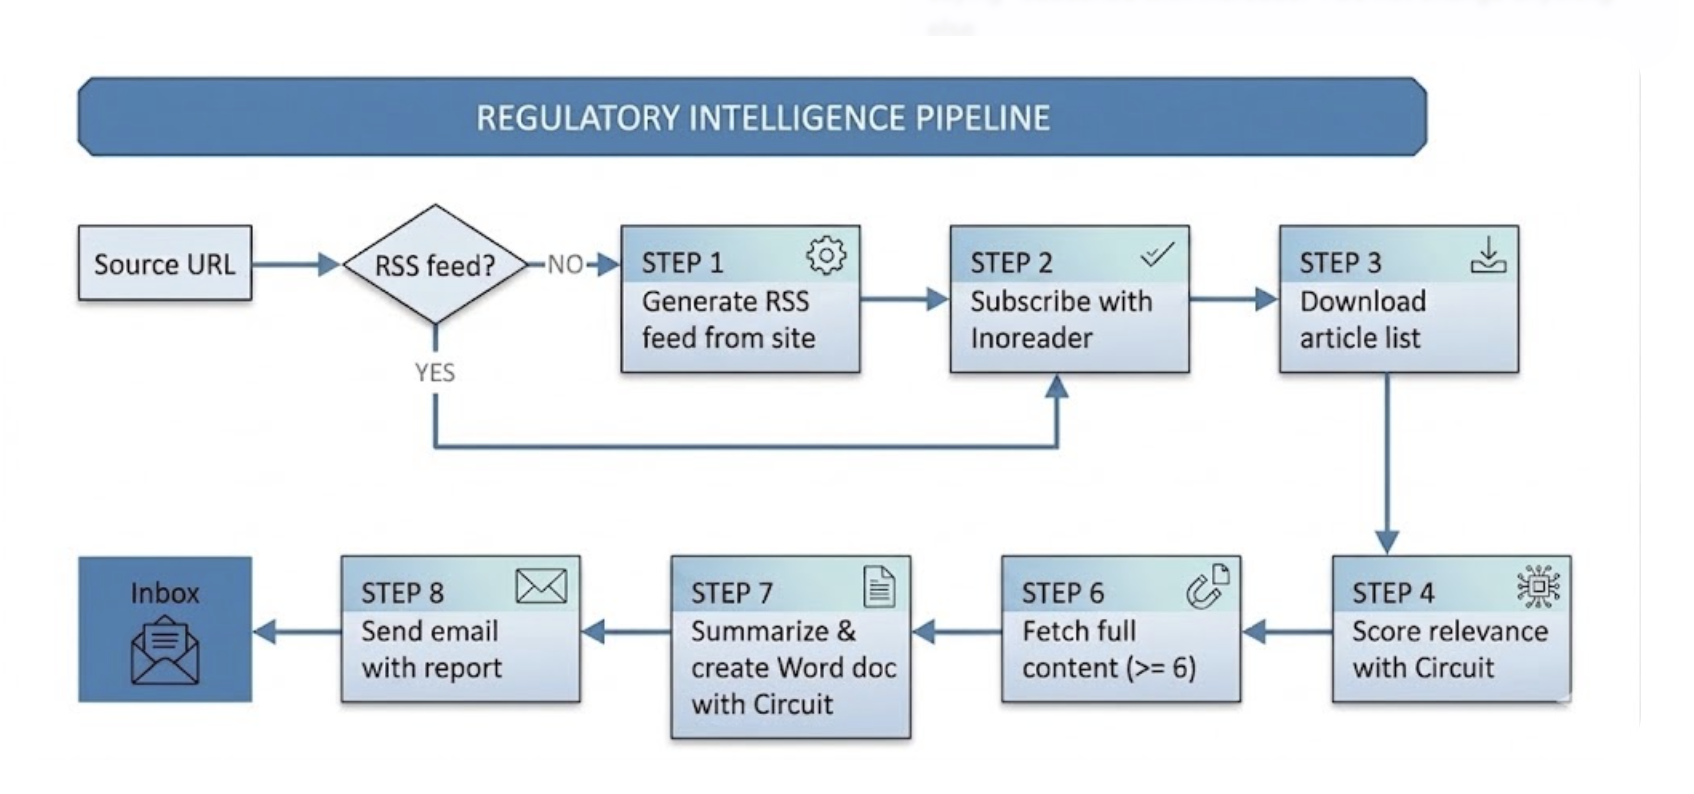

## Setup & Imports

In [1]:
import json
import os
import sys

# Add project root to path
PROJECT_ROOT = os.path.dirname(os.getcwd())
sys.path.insert(0, PROJECT_ROOT)

from scripts.common import (
    DATA_DIR,
    DAYS_BACK,
    load_credentials,
    get_inoreader_client,
    get_rss_client,
)
from evaluation.scorer import evaluate_articles
from summarize import ReportSummarizer
from clients.email_client import EmailClient

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")

/Users/wbickelm/anaconda3/envs/reg_intel/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.0.post2)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(
/Users/wbickelm/anaconda3/envs/reg_intel/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: /Users/wbickelm/Documents/code_projects/regulatory_intelligence
Data directory: /Users/wbickelm/Documents/code_projects/regulatory_intelligence/data


## Configuration

In [2]:
SOURCE_URL = (
    "https://www.skadden.com/insights"
    "?skip=0&panelid=tab-find-mode&paneltogglestate=2"
    "&type=9cbfe518-3bc0-4632-ae13-6ac9cee8eb31&hassearched=true"
)
TARGET_FOLDER = "test_folder1"
OUTPUT_FILE = os.path.join(DATA_DIR, "ArticleItem_dataclass_example.json")
EMAIL_RECIPIENTS = os.getenv("REPORT_RECIPIENTS", "").split(",")
RELEVANCE_THRESHOLD = 6

print(f"Source URL: {SOURCE_URL[:60]}...")
print(f"Target folder: {TARGET_FOLDER}")
print(f"Days back: {DAYS_BACK}")
print(f"Relevance threshold: >= {RELEVANCE_THRESHOLD}")

Source URL: https://www.skadden.com/insights?skip=0&panelid=tab-find-mod...
Target folder: test_folder1
Days back: 1
Relevance threshold: >= 6


## Initialize Clients

In [3]:
creds = load_credentials()
rss_client = get_rss_client(creds)
inoreader = get_inoreader_client(creds)

print("✅ Credentials loaded")
print("✅ RSS.app client initialized")
print("✅ Inoreader client initialized")

✅ All credentials loaded from .env
✅ Credentials loaded
✅ RSS.app client initialized
✅ Inoreader client initialized


---
## Step 1: Generate RSS Feed

In [4]:
 # https://www.skadden.com/insights?skip=0&panelid=tab-find-mode&paneltogglestate=2&type=9cbfe518-3bc0-4632-ae13-6ac9cee8eb31&hassearched=true


print(f"Generating RSS feed for:\n  {SOURCE_URL}")
feed_response = rss_client.create_feed_sync(SOURCE_URL)

if not feed_response:
    raise RuntimeError("❌ Failed to generate RSS feed")

feed_url = feed_response.feed_url
print(f"\n✅ RSS feed generated: {feed_url}")

Generating RSS feed for:
  https://www.skadden.com/insights?skip=0&panelid=tab-find-mode&paneltogglestate=2&type=9cbfe518-3bc0-4632-ae13-6ac9cee8eb31&hassearched=true

--- Generating RSS feed for: https://www.skadden.com/insights?skip=0&panelid=tab-find-mode&paneltogglestate=2&type=9cbfe518-3bc0-4632-ae13-6ac9cee8eb31&hassearched=true ---
✅ Feed successfully generated!
Title: Insights | Skadden, Arps, Slate, Meagher & Flom LLP
RSS Feed URL: https://rss.app/feeds/OQjjnwHJflHsq1D5.xml

✅ RSS feed generated: https://rss.app/feeds/OQjjnwHJflHsq1D5.xml


## Step 2: Subscribe in Inoreader

In [5]:
print(f"Subscribing feed to Inoreader folder '{TARGET_FOLDER}'...")
inoreader.add_feed_to_folder_sync(feed_url, TARGET_FOLDER)
print(f"✅ Feed subscribed to folder: {TARGET_FOLDER}")

Subscribing feed to Inoreader folder 'test_folder1'...

--- Subscribing to https://rss.app/feeds/OQjjnwHJflHsq1D5.xml ---
✅ Subscribed! Feed ID: feed/https://rss.app/feeds/OQjjnwHJflHsq1D5.xml

--- Moving feed to folder: 'test_folder1' ---
🚀 Successfully added feed to 'test_folder1'!
✅ Feed subscribed to folder: test_folder1


## Step 3: Fetch Articles (Metadata Only)

In [6]:
print(f"Fetching articles from '{TARGET_FOLDER}' (last {DAYS_BACK} day(s))...")
articles = inoreader.get_folder_articles_sync(TARGET_FOLDER, days_back=DAYS_BACK)

if not articles:
    raise RuntimeError("⚠️ No articles found in timeframe")

print(f"\n✅ Found {len(articles)} articles")
for i, a in enumerate(articles[:5], 1):
    print(f"  {i}. {a.title[:60]}...")

Fetching articles from 'test_folder1' (last 1 day(s))...

--- Fetching articles from 'test_folder1' (Last 1 days) ---
✅ Found 50 articles.

📰 Conflict Minerals Disclosures Due June 1, 2026 | Skadden, Arps, Slate, Meagher
🕒 2026-04-30 20:00:00
🔗 https://www.skadden.com/insights/publications/2026/05/conflict-minerals-disclosures-due-june-1-2026

📰 PRA Proposes Funded Reinsurance Reform | Skadden, Arps, Slate, Meagher
🕒 2026-04-29 20:00:00
🔗 https://www.skadden.com/insights/publications/2026/04/pra-proposes-funded-reinsurance-reform

📰 Streamlining the UK IPO Process: The FCA’s Proposed Changes to Rules on IPO Investment Research | Skadden, Arps, Slate, Meagher
🕒 2026-04-29 20:00:00
🔗 https://www.skadden.com/insights/publications/2026/04/streamlining-the-uk-ipo-process

📰 Businesses Beware: New York's FAIR Business Practices Act Now in Effect | Skadden, Arps, Slate, Meagher
🕒 2026-04-28 20:00:00
🔗 https://www.skadden.com/insights/publications/2026/04/businesses-beware-new-yorks-fair-busin

## Step 4: Evaluate Relevance (Circuit LLM)

In [7]:
print(f"Evaluating {len(articles)} articles for Cisco relevance...")
evaluated_articles = evaluate_articles(articles)

scored = [a for a in evaluated_articles if a.relevance_score is not None]
avg_score = sum(a.relevance_score for a in scored) / len(scored) if scored else 0

print(f"\n✅ Evaluated {len(scored)}/{len(evaluated_articles)} articles")
print(f"📊 Average relevance score: {avg_score:.1f}/10")

Evaluating 50 articles for Cisco relevance...

[1/50] Evaluating: Conflict Minerals Disclosures Due June 1, 2026 | Skadden, Arps, Slate, Meagher
  → Score: 7/10 | review
  → The rule governs disclosure of conflict minerals in manufactured products, which directly implicates Cisco's hardware su

[2/50] Evaluating: PRA Proposes Funded Reinsurance Reform | Skadden, Arps, Slate, Meagher
  → Score: 4/10 | monitor
  → The article discusses UK PRA reforms to funded reinsurance capital within Solvency UK. It is not directly related to Cis

[3/50] Evaluating: Streamlining the UK IPO Process: The FCA’s Proposed Changes to Rules on IPO Investment Research | Skadden, Arps, Slate, Meagher
  → Score: 5/10 | monitor
  → Moderate relevance. The changes concern UK IPO investment research rules, which could affect cross-border listings, issu

[4/50] Evaluating: Businesses Beware: New York's FAIR Business Practices Act Now in Effect | Skadden, Arps, Slate, Meagher
  → Score: 6/10 | monitor
  → The FAIR A

## Step 5: Save Results

In [8]:
os.makedirs(DATA_DIR, exist_ok=True)
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump([a.to_dict() for a in evaluated_articles], f, indent=2, ensure_ascii=False)

print(f"✅ Results saved to: {OUTPUT_FILE}")

✅ Results saved to: /Users/wbickelm/Documents/code_projects/regulatory_intelligence/data/ArticleItem_dataclass_example.json


## Step 6: Fetch Full Content for High Scorers

In [9]:
high_scorers = [
    a for a in evaluated_articles 
    if a.relevance_score is not None and a.relevance_score >= RELEVANCE_THRESHOLD
]

print(f"Fetching full content for {len(high_scorers)} high-scoring articles (>= {RELEVANCE_THRESHOLD})...\n")

for article in high_scorers:
    print(f"{'─' * 60}")
    print(f"📰 {article.title}")
    print(f"🔗 {article.url}")
    content = inoreader.get_article_content_sync(article.item_id)
    if content:
        plain = inoreader._strip_html(content)
        preview = plain[:300] + ("..." if len(plain) > 300 else "")
        print(f"📄 Preview: {preview}\n")
        article.full_content = plain
    else:
        print("⚠️ No full content available\n")
        article.full_content = ""

# Re-save with full content
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump([a.to_dict() for a in evaluated_articles], f, indent=2, ensure_ascii=False)

print(f"\n✅ Full content fetched for {len(high_scorers)} articles")

Fetching full content for 12 high-scoring articles (>= 6)...

────────────────────────────────────────────────────────────
📰 Conflict Minerals Disclosures Due June 1, 2026 | Skadden, Arps, Slate, Meagher
🔗 https://www.skadden.com/insights/publications/2026/05/conflict-minerals-disclosures-due-june-1-2026
📄 Preview: Conflict minerals disclosures on Form SD for calendar year 2025 are required to be filed with the Securities and Exchange Commission (SEC) no later than June 1, 2026.1 The conflict minerals disclosure rules and related guidance have remained at a practical standstill for the past few years following...

────────────────────────────────────────────────────────────
📰 Businesses Beware: New York's FAIR Business Practices Act Now in Effect | Skadden, Arps, Slate, Meagher
🔗 https://www.skadden.com/insights/publications/2026/04/businesses-beware-new-yorks-fair-business-practices-act-now-in-effect
📄 Preview: Executive Summary What’s new: The FAIR Act is the most significant revamp 

## Summary

In [10]:
print("=" * 60)
print("📊 PIPELINE SUMMARY")
print("=" * 60)
print(f"Source URL:     {SOURCE_URL[:50]}...")
print(f"RSS Feed URL:   {feed_url}")
print(f"Folder:         {TARGET_FOLDER}")
print(f"Articles:       {len(evaluated_articles)}")
print(f"Scored:         {len(scored)}/{len(evaluated_articles)}")
print(f"Avg Score:      {avg_score:.1f}/10")
print(f"High Scorers:   {len(high_scorers)} (>= {RELEVANCE_THRESHOLD})")
print("=" * 60)

print("\n🏆 TOP ARTICLES BY RELEVANCE:")
for a in sorted(scored, key=lambda x: x.relevance_score, reverse=True)[:5]:
    action = a.evaluation.get("action_needed", "n/a") if a.evaluation else "n/a"
    print(f"  [{a.relevance_score:2d}/10] [{action:>7s}] {a.title[:50]}")

📊 PIPELINE SUMMARY
Source URL:     https://www.skadden.com/insights?skip=0&panelid=ta...
RSS Feed URL:   https://rss.app/feeds/OQjjnwHJflHsq1D5.xml
Folder:         test_folder1
Articles:       50
Scored:         50/50
Avg Score:      3.9/10
High Scorers:   12 (>= 6)

🏆 TOP ARTICLES BY RELEVANCE:
  [ 7/10] [ review] Conflict Minerals Disclosures Due June 1, 2026 | S
  [ 7/10] [monitor] Reminder: Effective June 30, Companies Barred From
  [ 7/10] [monitor] EU Adopts Revised Technology Licensing Rules | Ska
  [ 7/10] [monitor] European Commission Proposes Industrial Accelerato
  [ 7/10] [monitor] What Next-Gen AI Tools Mean for European and US Cy


---
## Step 7: Generate Word Document Report

In [11]:
if not high_scorers:
    print("⚠️ No high-scoring articles to summarize")
else:
    print(f"Generating Word doc for {len(high_scorers)} high-scoring articles...")
    
    summarizer = ReportSummarizer()
    docx_path = os.path.join(DATA_DIR, "executive_briefing.docx")
    
    summarizer.generate_docx(
        high_scorers,
        output_path=docx_path,
        title="Skadden Insights — Executive Briefing"
    )
    
    print(f"\n📄 Word report saved to: {docx_path}")

Generating Word doc for 12 high-scoring articles...

[1/12] Summarizing: Conflict Minerals Disclosures Due June 1, 2026 | Skadden, Arps, Slate, Meagher

[2/12] Summarizing: Businesses Beware: New York's FAIR Business Practices Act Now in Effect | Skadden, Arps, Slate, Meagher

[3/12] Summarizing: Reminder: Effective June 30, Companies Barred From Defense Contracts if They Retain Third Parties Lobbying for Certain Chinese Military Companies | Skadden, Arps, Slate, Meagher

[4/12] Summarizing: EU Adopts Revised Technology Licensing Rules | Skadden, Arps, Slate, Meagher

[5/12] Summarizing: European Commission Proposes Industrial Accelerator Act: Prioritizing Strategic Sectors, ‘Made in EU’ Requirements and FDI Controls | Insights | Skadden, Arps, Slate, Meagher

[6/12] Summarizing: What Next-Gen AI Tools Mean for European and US Cybersecurity and Privacy Regulation | Insights | Skadden, Arps, Slate, Meagher

[7/12] Summarizing: Proposed California Antitrust Legislation Could Significantl

## Step 8: Email Report

In [12]:
recipients = [e.strip() for e in EMAIL_RECIPIENTS if e.strip()]

if not recipients:
    print("⚠️ No REPORT_RECIPIENTS configured — skipping email")
elif not high_scorers:
    print("⚠️ No high-scoring articles — skipping email")
else:
    print(f"Emailing report to {len(recipients)} recipient(s)...")
    
    try:
        email_client = EmailClient()
        success = email_client.send_report(
            to_emails=recipients,
            subject="Regulatory Intelligence Briefing — Skadden Insights",
            body_html=f"""
            <h2>Regulatory Intelligence Briefing</h2>
            <p>Attached is the executive briefing covering {len(high_scorers)} 
            high-relevance articles from Skadden Insights.</p>
            <p><em>Generated automatically by the Regulatory Intelligence system.</em></p>
            """,
            attachment_path=docx_path,
        )
        if success:
            print(f"✅ Email sent to: {', '.join(recipients)}")
        else:
            print("⚠️ Email send failed")
    except ValueError as e:
        print(f"⚠️ Skipping email: {e}")

Emailing report to 1 recipient(s)...
✅ Email sent to: wbickelm@cisco.com


In [13]:
# You are a regulatory intelligence analyst for Cisco Systems. Your task is to 
# evaluate the relevance of a regulatory article to Cisco's business 
# interests and compliance obligations.

# Cisco's core business areas include:
# - Networking infrastructure (routers, switches, SD-WAN, wireless/Wi-Fi)
# - Cybersecurity (firewalls, XDR, SASE, zero-trust, threat intelligence)
# - Collaboration (Webex, unified communications, video conferencing)
# - Cloud & SaaS services (cloud security, observability, AppDynamics, ThousandEyes)
# - Data center & compute (servers, hyperconverged infrastructure)
# - IoT / industrial networking
# - AI & machine learning platforms
# - Software-defined networking and automation

# Regulatory domains of interest:
# - AI & emerging technology governance
# - Cybersecurity & critical infrastructure protection
# - Data protection & privacy (GDPR, CCPA, cross-border data flows)
# - Telecommunications regulation
# - Cloud services & FedRAMP authorization
# - Competition / antitrust
# - Trade, export controls & sanctions
# - Supply chain security & hardware sourcing
# - Environmental sustainability & reporting (ESG)
# - Financial reporting & tax
# - Labor & workforce regulations

# For each article, assess:
# 1. DIRECT RELEVANCE — Does this article directly affect Cisco products, services, or operations?
# 2. INDIRECT RELEVANCE — Could this article affect Cisco's customers, partners, or competitive landscape?
# 3. COMPLIANCE IMPACT — Does this create new compliance obligations, reporting requirements, or deadlines?
# 4. STRATEGIC SIGNIFICANCE — Does this signal a regulatory trend that Cisco should monitor or prepare for?

# Scoring rubric (0 – 10):
#   0 – 2   No relevance to Cisco's business or regulatory posture.
#   3 – 4   Tangential relevance; affects adjacent industries or very broad regulations.
#   5 – 6   Moderate relevance; affects a Cisco business area or customer segment.
#   7 – 8   High relevance; directly impacts Cisco products, compliance, or market position.
#   9 – 10  Critical relevance; requires immediate attention or action by Cisco teams.

# INPUT:
# - Title: {title}
# - URL: {url}
# - Published: {published_at}
# - Summary: {summary}
# - Full Content: {full_content}

# OUTPUT (respond in valid JSON only):
# {{
#   "relevance_score": <integer 0-10>,
#   "reasoning": "<2-3 sentence explanation of the score>",
#   "primary_domain": "<most relevant regulatory domain from the list above>",
#   "cisco_business_areas": ["<list of affected Cisco business areas>"],
#   "action_needed": "<none | monitor | review | urgent>"
# }}
